<style>
.reveal { font-family: 'Segoe UI', system-ui, sans-serif; font-size: 1.05em; }
.reveal h2 { color: #0D2240; border-bottom: 2.5px solid #1A7A9A; padding-bottom: .3em; }
.reveal h3 { color: #1A7A9A; }
.reveal .slides section { text-align: left; }
.reveal pre { font-size: .75em; box-shadow: none; border-left: 3px solid #1A7A9A; }
.defn { background:#EAF6FA; border-left:4px solid #1A7A9A; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.nota { background:#FFF8E1; border-left:4px solid #C8961E; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.alerta { background:#FDE8E8; border-left:4px solid #C0392B; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.ok { background:#E8F5E9; border-left:4px solid #2E7D32; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
</style>

## Modelado de Entradas
### T3.1 · Modelado de Sistemas bajo Incertidumbre
Universidad de los Andes · Ingeniería Industrial

*Del dato observado a la distribución de probabilidad.*

## Agenda

1. Motivación: tiempos del banco y la pregunta por el modelo de colas.
2. Familias de distribuciones y guía por el coeficiente de variación.
3. **Construcción paso a paso** del histograma, la función de distribución empírica y el gráfico Q-Q.
4. **Pruebas de independencia**: autocorrelación lagueada y correlograma.
5. Estimación por **máxima verosimilitud** y criterios de información AIC/BIC.
6. Pruebas de bondad de ajuste sobre los 15 datos del banco:
   chi-cuadrado, Kolmogorov–Smirnov y **Anderson–Darling** — cada una con cálculo manual.
7. Cierre del problema con el banco completo ($n=80$) y su impacto en $W_q$.
8. Qué hacer sin datos.

## El problema que nos motiva

<div class='defn'>
Un banco registra <strong>15 tiempos de atención</strong> (minutos) en una ventanilla:
<br><br>
<code>0.7, 0.8, 0.9, 1.1, 1.2, 1.5, 1.6, 1.8, 2.1, 2.4, 2.8, 3.1, 3.4, 4.2, 5.6</code>
<br><br>
<strong>Pregunta central:</strong> ¿podemos modelar la ventanilla como $M/M/1$
(llegadas Poisson + servicio exponencial)?
</div>

Todo el tema gira en torno a esta pregunta. Vamos a responderla paso a paso.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, special

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.prop_cycle": plt.cycler(color=["#1A7A9A", "#C62828", "#C8961E", "#2E7D32", "#7D3C98"]),
})

# Datos del banco (15 tiempos de servicio, minutos)
x_bank = np.array([0.7, 0.8, 0.9, 1.1, 1.2, 1.5, 1.6, 1.8,
                   2.1, 2.4, 2.8, 3.1, 3.4, 4.2, 5.6])
n = x_bank.size
xbar = x_bank.mean()
s = x_bank.std(ddof=1)
cv = s / xbar
lam = 1.0 / xbar

print(f"n = {n}")
print(f"Media muestral:             {xbar:.3f} min")
print(f"Desviación estándar:        {s:.3f} min")
print(f"Coeficiente de variación:   {cv:.3f}")
print(f"Estimador exponencial:      lambda_hat = 1/media = {lam:.3f} min^-1")

print("\nGuía rápida por coeficiente de variación:")
print(f"  CV observado = {cv:.2f}  -> sugiere Erlang-k con k ≈ 1/CV^2 = {1/cv**2:.1f}")
print("  (CV < 1 => servicio regular, no exponencial)")


n = 15
Media muestral:             2.213 min
Desviación estándar:        1.397 min
Coeficiente de variación:   0.631
Estimador exponencial:      lambda_hat = 1/media = 0.452 min^-1

Guía rápida por coeficiente de variación:
  CV observado = 0.63  -> sugiere Erlang-k con k ≈ 1/CV^2 = 2.5
  (CV < 1 => servicio regular, no exponencial)


## Familias de distribuciones para sistemas de colas

Antes de elegir, miramos las formas posibles. El coeficiente de variación es la firma de cada familia.

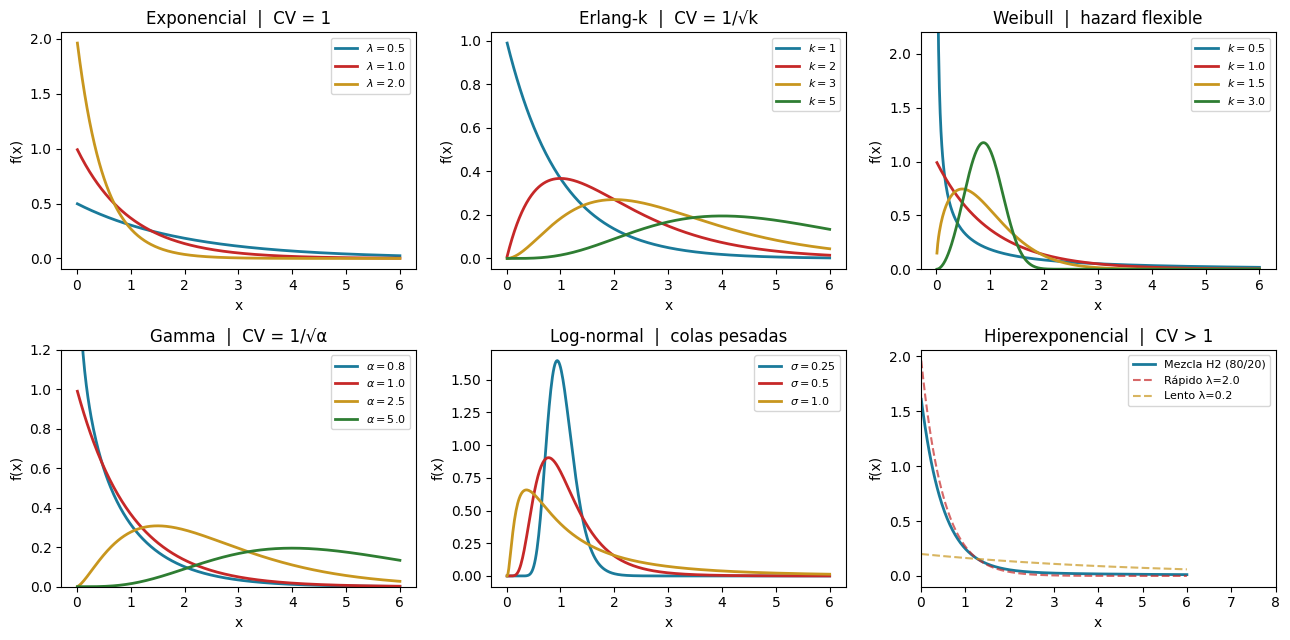

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))

xgrid = np.linspace(0.01, 6, 400)

# Exponencial
ax = axes[0, 0]
for lam_i in (0.5, 1.0, 2.0):
    ax.plot(xgrid, stats.expon.pdf(xgrid, scale=1/lam_i), lw=2,
            label=f"$\\lambda={lam_i}$")
ax.set_title("Exponencial  |  CV = 1")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(fontsize=8)

# Erlang-k
ax = axes[0, 1]
for k in (1, 2, 3, 5):
    ax.plot(xgrid, stats.erlang.pdf(xgrid, a=k, scale=1), lw=2, label=f"$k={k}$")
ax.set_title("Erlang-k  |  CV = 1/√k")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(fontsize=8)

# Weibull (densidades)
ax = axes[0, 2]
for ksh in (0.5, 1.0, 1.5, 3.0):
    ax.plot(xgrid, stats.weibull_min.pdf(xgrid, c=ksh, scale=1), lw=2,
            label=f"$k={ksh}$")
ax.set_title("Weibull  |  hazard flexible")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(fontsize=8)
ax.set_ylim(0, 2.2)

# Gamma
ax = axes[1, 0]
for a in (0.8, 1.0, 2.5, 5.0):
    ax.plot(xgrid, stats.gamma.pdf(xgrid, a=a, scale=1), lw=2, label=f"$\\alpha={a}$")
ax.set_title("Gamma  |  CV = 1/√α")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(fontsize=8)
ax.set_ylim(0, 1.2)

# Log-normal
ax = axes[1, 1]
for sig in (0.25, 0.5, 1.0):
    ax.plot(xgrid, stats.lognorm.pdf(xgrid, s=sig, scale=1), lw=2,
            label=f"$\\sigma={sig}$")
ax.set_title("Log-normal  |  colas pesadas")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(fontsize=8)

# Hiperexponencial H2
ax = axes[1, 2]
p, lam1, lam2 = 0.8, 2.0, 0.2
ax.plot(xgrid, p*stats.expon.pdf(xgrid, scale=1/lam1) + (1-p)*stats.expon.pdf(xgrid, scale=1/lam2),
        lw=2, label="Mezcla H2 (80/20)")
ax.plot(xgrid, stats.expon.pdf(xgrid, scale=1/lam1), "--", lw=1.5, alpha=0.7,
        label=f"Rápido λ={lam1}")
ax.plot(xgrid, stats.expon.pdf(xgrid, scale=1/lam2), "--", lw=1.5, alpha=0.7,
        label=f"Lento λ={lam2}")
ax.set_title("Hiperexponencial  |  CV > 1")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(fontsize=8)
ax.set_xlim(0, 8)

plt.tight_layout(); plt.show()


## Weibull y tasa de falla: la firma del desgaste

La Weibull se caracteriza por su **tasa de falla** (función hazard) $h(x) = f(x)/[1-F(x)]$.
Con distintos $k$ aparecen tres regímenes físicos:
- $k<1$: mortalidad infantil (equipos nuevos defectuosos).
- $k=1$: exponencial (tasa constante, sin memoria).
- $k>1$: desgaste (equipos envejecen).

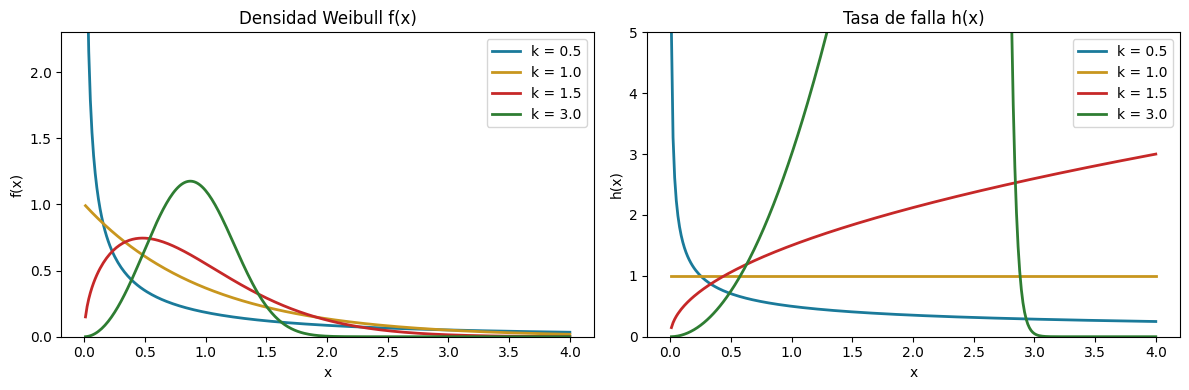

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

xgrid = np.linspace(0.01, 4, 300)
for ksh, color in zip([0.5, 1.0, 1.5, 3.0],
                     ["#1A7A9A", "#C8961E", "#C62828", "#2E7D32"]):
    pdf = stats.weibull_min.pdf(xgrid, c=ksh, scale=1)
    sf = stats.weibull_min.sf(xgrid, c=ksh, scale=1)
    ax1.plot(xgrid, pdf, color=color, lw=2, label=f"k = {ksh}")
    ax2.plot(xgrid, pdf/np.maximum(sf, 1e-9), color=color, lw=2,
             label=f"k = {ksh}")

ax1.set_title("Densidad Weibull f(x)"); ax1.set_xlabel("x"); ax1.set_ylabel("f(x)")
ax1.set_ylim(0, 2.3); ax1.legend()
ax2.set_title("Tasa de falla h(x)"); ax2.set_xlabel("x"); ax2.set_ylabel("h(x)")
ax2.set_ylim(0, 5); ax2.legend()
plt.tight_layout(); plt.show()


## Construcción de un histograma paso a paso

1. **Rango** $R = x_{\max} - x_{\min}$.
2. **Número de intervalos** $k$ (Sturges: $k = 1 + 3{,}322 \log_{10} n$).
3. **Amplitud** $w = R/k$.
4. **Frecuencias** $f_j$ = número de datos en $[a_j, a_j + w)$.
5. **Graficar** barras adyacentes.

*Lo aplicamos sobre los 15 tiempos del banco.*

1. Rango:                R = 5.60 - 0.70 = 4.90
2. Número de intervalos: k = ceil(1 + 3.322 * log10(15)) = 5
3. Amplitud:             w = 4.90 / 5 = 0.980

4. Frecuencias por intervalo:
Intervalo           f_j
------------------------
[ 0.70,  1.68)      7
[ 1.68,  2.66)      3
[ 2.66,  3.64)      3
[ 3.64,  4.62)      1
[ 4.62,  5.60)      1
Total                15


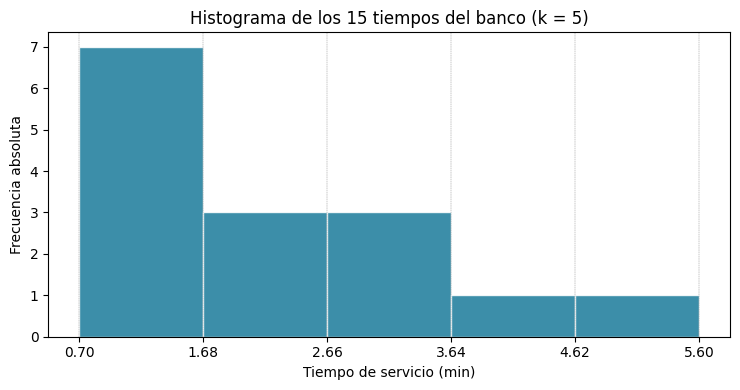

In [4]:
# Paso a paso sobre los 15 tiempos del banco
x_sorted = np.sort(x_bank)
R = x_sorted[-1] - x_sorted[0]
k_sturges = int(np.ceil(1 + 3.322 * np.log10(n)))
w = R / k_sturges

print(f"1. Rango:                R = {x_sorted[-1]:.2f} - {x_sorted[0]:.2f} = {R:.2f}")
print(f"2. Número de intervalos: k = ceil(1 + 3.322 * log10({n})) = {k_sturges}")
print(f"3. Amplitud:             w = {R:.2f} / {k_sturges} = {w:.3f}")

# Paso 4: frecuencias
edges = x_sorted[0] + w * np.arange(k_sturges + 1)
freq, _ = np.histogram(x_bank, bins=edges)
print("\n4. Frecuencias por intervalo:")
print(f"{'Intervalo':<18}{'f_j':>5}")
print("-" * 24)
for j in range(k_sturges):
    print(f"[{edges[j]:5.2f}, {edges[j+1]:5.2f})  {freq[j]:>5}")
print(f"{'Total':<18}{freq.sum():>5}")

# Paso 5: gráfica con los mismos bordes
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(x_bank, bins=edges, color="#1A7A9A", edgecolor="white", alpha=0.85)
for e in edges:
    ax.axvline(e, color="gray", lw=0.3, ls="--")
ax.set_xlabel("Tiempo de servicio (min)")
ax.set_ylabel("Frecuencia absoluta")
ax.set_title(f"Histograma de los 15 tiempos del banco (k = {k_sturges})")
ax.set_xticks(np.round(edges, 2))
plt.tight_layout(); plt.show()


## Función de distribución empírica

$$
\hat F_n(x) \;=\; \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}\{X_i \le x\}
$$

Es una **escalera** con saltos de $1/n$ en cada observación ordenada.
Se compara con la distribución teórica ajustada.

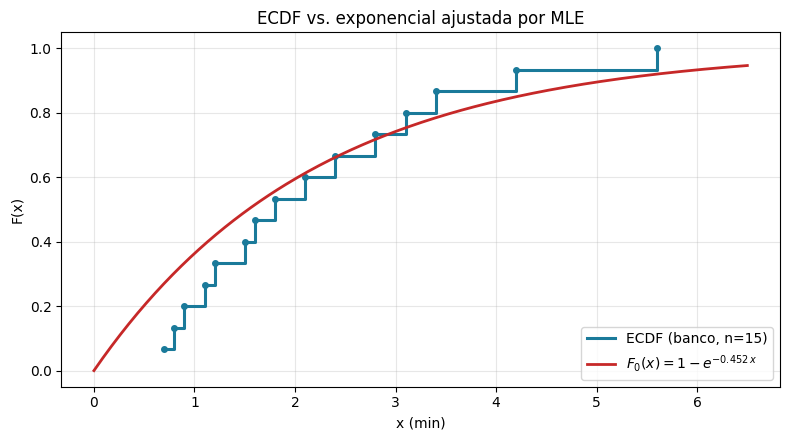


Valores F_0(x_(i)) = 1 - exp(-lambda * x_(i)):
  i   x_(i)    F_0(x_(i))       i/n
  1    0.70        0.2711    0.0667
  2    0.80        0.3033    0.1333
  3    0.90        0.3341    0.2000
  4    1.10        0.3916    0.2667
  5    1.20        0.4185    0.3333
  6    1.50        0.4922    0.4000
  7    1.60        0.5147    0.4667
  8    1.80        0.5566    0.5333
  9    2.10        0.6128    0.6000
 10    2.40        0.6619    0.6667
 11    2.80        0.7178    0.7333
 12    3.10        0.7536    0.8000
 13    3.40        0.7848    0.8667
 14    4.20        0.8501    0.9333
 15    5.60        0.9204    1.0000


In [5]:
# ECDF manual + comparación con la CDF exponencial ajustada
fig, ax = plt.subplots(figsize=(8, 4.5))

x_plot = np.concatenate(([0], np.repeat(x_sorted, 2), [6]))
y_plot = np.concatenate(([0, 0], np.repeat(np.arange(1, n+1) / n, 2)))[:-1]
ax.step(x_sorted, np.arange(1, n+1)/n, where="post",
        color="#1A7A9A", lw=2.2, label="ECDF (banco, n=15)")
ax.plot(x_sorted, np.arange(1, n+1)/n, "o", color="#1A7A9A", ms=4)

xgrid = np.linspace(0, 6.5, 300)
ax.plot(xgrid, stats.expon.cdf(xgrid, scale=xbar), color="#C62828", lw=2,
        label=f"$F_0(x) = 1 - e^{{-{lam:.3f}\,x}}$")

ax.set_xlabel("x (min)"); ax.set_ylabel("F(x)")
ax.set_title("ECDF vs. exponencial ajustada por MLE")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nValores F_0(x_(i)) = 1 - exp(-lambda * x_(i)):")
print(f"{'i':>3}{'x_(i)':>8}{'F_0(x_(i))':>14}{'i/n':>10}")
for i, xi in enumerate(x_sorted, 1):
    Fi = 1 - np.exp(-lam * xi)
    print(f"{i:>3}{xi:>8.2f}{Fi:>14.4f}{i/n:>10.4f}")


## Construcción paso a paso de un gráfico Q-Q

1. **Ordenar** los datos: $x_{(1)} \le x_{(2)} \le \cdots \le x_{(n)}$.
2. **Probabilidades de trazado** $p_i = (i-0{,}5)/n$.
3. **Cuantiles teóricos** $q_i = F^{-1}(p_i;\hat\theta)$.
4. **Graficar** $(q_i, x_{(i)})$ y añadir la recta $y = x$.

Si los datos provienen de la distribución teórica, los puntos se alinean sobre la recta.

In [6]:
# Ejemplo MANUAL con n = 3 datos y exponencial lambda = 1
x_small = np.array([2.1, 0.5, 1.2])
x_ord = np.sort(x_small)
n_s = len(x_small)
p_i = (np.arange(1, n_s + 1) - 0.5) / n_s
q_i = -np.log(1 - p_i)        # F^{-1}(p) para Exp(1)

print("Ejemplo manual (n = 3, Exp(lambda = 1)):")
print(f"{'i':>3}{'x_(i)':>10}{'p_i':>10}{'q_i = -ln(1-p_i)':>22}")
for i in range(n_s):
    print(f"{i+1:>3}{x_ord[i]:>10.2f}{p_i[i]:>10.3f}{q_i[i]:>22.3f}")
print("\nPuntos (q_i, x_(i)):", [f"({q:.2f}, {x:.1f})" for q, x in zip(q_i, x_ord)])


Ejemplo manual (n = 3, Exp(lambda = 1)):
  i     x_(i)       p_i      q_i = -ln(1-p_i)
  1      0.50     0.167                 0.182
  2      1.20     0.500                 0.693
  3      2.10     0.833                 1.792

Puntos (q_i, x_(i)): ['(0.18, 0.5)', '(0.69, 1.2)', '(1.79, 2.1)']


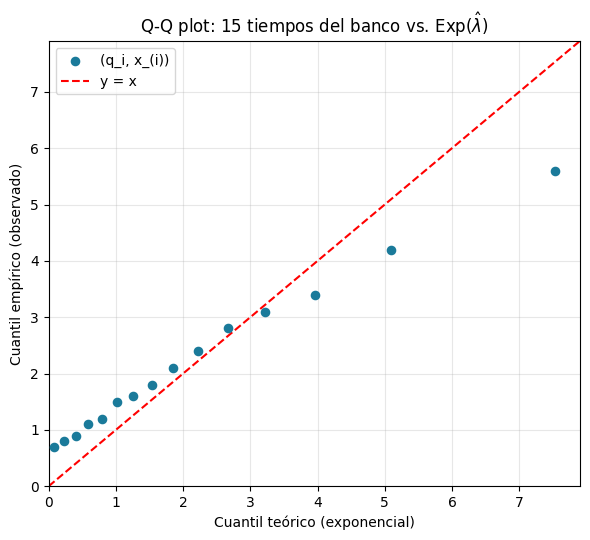


Lectura visual:
 - Si los puntos caen sobre la diagonal → la exponencial es adecuada.
 - Aquí hay curvatura en 'S': demasiados valores pequeños esperados,
   demasiados valores grandes predichos por la exponencial.
 - Patrón consistente con CV = 0.63 < 1 (Erlang o Gamma).


In [7]:
# Aplicación sobre los 15 datos del banco
p_i = (np.arange(1, n + 1) - 0.5) / n
q_theor = stats.expon.ppf(p_i, scale=xbar)  # cuantiles teóricos exponenciales

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(q_theor, x_sorted, color="#1A7A9A", s=35, zorder=3, label="(q_i, x_(i))")
lims = [0, max(q_theor.max(), x_sorted.max()) * 1.05]
ax.plot(lims, lims, "r--", lw=1.5, label="y = x")
ax.set_xlabel("Cuantil teórico (exponencial)")
ax.set_ylabel("Cuantil empírico (observado)")
ax.set_title("Q-Q plot: 15 tiempos del banco vs. Exp($\\hat\\lambda$)")
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout(); plt.show()

print(f"\nLectura visual:")
print(f" - Si los puntos caen sobre la diagonal → la exponencial es adecuada.")
print(f" - Aquí hay curvatura en 'S': demasiados valores pequeños esperados,")
print(f"   demasiados valores grandes predichos por la exponencial.")
print(f" - Patrón consistente con CV = {cv:.2f} < 1 (Erlang o Gamma).")


## Independencia temporal y autocorrelación lagueada

**Coeficiente de autocorrelación de orden $k$** (Pearson lagueado):
$$
r_k \;=\; \frac{\sum_{t=k+1}^{n} (Y_t - \bar Y)(Y_{t-k} - \bar Y)}
                   {\sum_{t=1}^{n} (Y_t - \bar Y)^2}
$$

Bajo $H_0: \rho_k = 0$ y muestra grande, $r_k \approx \mathcal{N}(0,\; 1/n)$.

**Bandas de confianza al 95%:** $\pm 1{,}96/\sqrt{n}$.

El **correlograma** (ACF) grafica $r_k$ vs. $k$; cualquier barra que sobresalga de las bandas indica autocorrelación significativa en ese rezago.

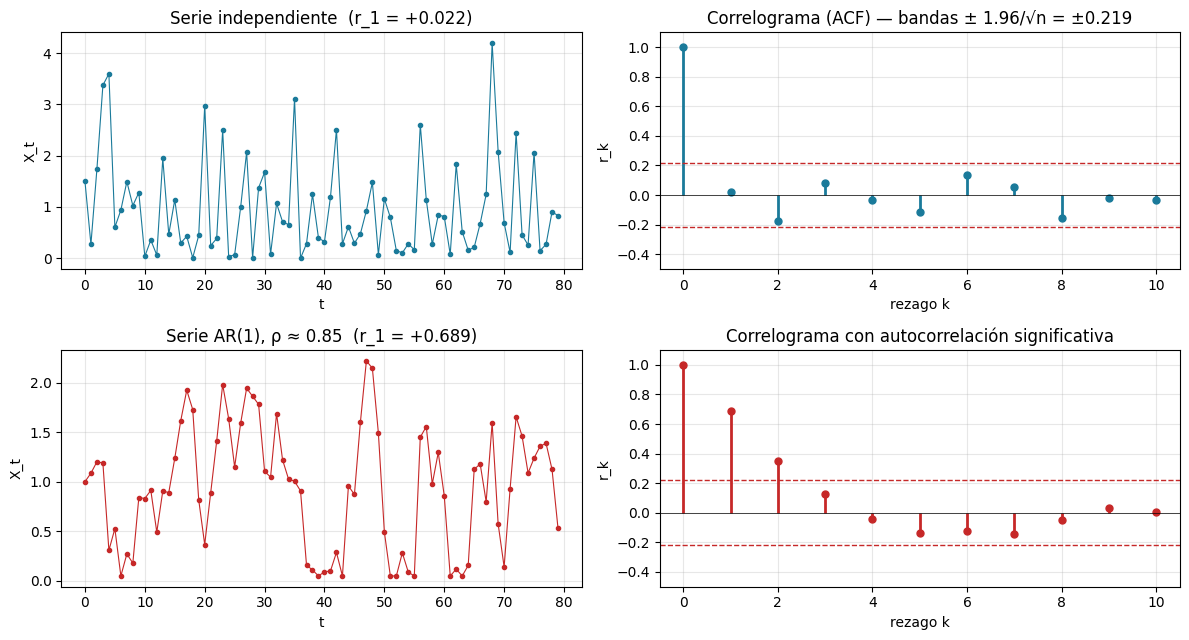


Bandas 95%: ± 0.219
  k    r_k (ind.)      r_k (AR)
  1        0.022         0.689*
  2       -0.176         0.348*
  3        0.081         0.126 
  4       -0.032        -0.045 
  5       -0.111        -0.135 
  6        0.138        -0.122 
  7        0.056        -0.140 
  8       -0.154        -0.050 
  9       -0.023         0.034 
 10       -0.033         0.007 
(* = fuera de las bandas de 95% → rechazar independencia en ese lag.)


In [8]:
def autocorr(y, k_max):
    """Devuelve [r_0, r_1, ..., r_{k_max}] (con r_0 = 1)."""
    y = np.asarray(y, dtype=float)
    n_ = y.size
    c0 = np.sum((y - y.mean())**2)
    return np.array([
        np.sum((y[k:] - y.mean()) * (y[:n_-k] - y.mean())) / c0
        for k in range(k_max + 1)
    ])

# Dos series de n = 80: independiente vs. AR(1) con rho = 0.85
np.random.seed(13)
serie_ind = stats.expon.rvs(scale=1.0, size=80)

np.random.seed(14)
eps = stats.norm.rvs(scale=0.45, size=80)
serie_ar = np.zeros(80); serie_ar[0] = 1.0
for t in range(1, 80):
    serie_ar[t] = 0.2 + 0.85 * serie_ar[t-1] + eps[t]
serie_ar = np.maximum(serie_ar, 0.05)

# Coeficientes lagueados r_1..r_10
k_max = 10
rk_ind = autocorr(serie_ind, k_max)
rk_ar = autocorr(serie_ar, k_max)
banda = 1.96 / np.sqrt(80)

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))

# Serie independiente: serie + correlograma
axes[0, 0].plot(serie_ind, color="#1A7A9A", marker="o", ms=3, lw=0.8)
axes[0, 0].set_title(f"Serie independiente  (r_1 = {rk_ind[1]:+.3f})")
axes[0, 0].set_xlabel("t"); axes[0, 0].set_ylabel("X_t"); axes[0, 0].grid(alpha=0.3)

axes[0, 1].vlines(range(k_max + 1), 0, rk_ind, color="#1A7A9A", lw=2)
axes[0, 1].plot(range(k_max + 1), rk_ind, "o", color="#1A7A9A", ms=5)
axes[0, 1].axhline(banda, ls="--", color="#C62828", lw=1)
axes[0, 1].axhline(-banda, ls="--", color="#C62828", lw=1)
axes[0, 1].axhline(0, color="black", lw=0.5)
axes[0, 1].set_title(f"Correlograma (ACF) — bandas ± 1.96/√n = ±{banda:.3f}")
axes[0, 1].set_xlabel("rezago k"); axes[0, 1].set_ylabel("r_k")
axes[0, 1].set_ylim(-0.5, 1.1); axes[0, 1].grid(alpha=0.3)

# Serie AR(1): serie + correlograma
axes[1, 0].plot(serie_ar, color="#C62828", marker="o", ms=3, lw=0.8)
axes[1, 0].set_title(f"Serie AR(1), ρ ≈ 0.85  (r_1 = {rk_ar[1]:+.3f})")
axes[1, 0].set_xlabel("t"); axes[1, 0].set_ylabel("X_t"); axes[1, 0].grid(alpha=0.3)

axes[1, 1].vlines(range(k_max + 1), 0, rk_ar, color="#C62828", lw=2)
axes[1, 1].plot(range(k_max + 1), rk_ar, "o", color="#C62828", ms=5)
axes[1, 1].axhline(banda, ls="--", color="#C62828", lw=1)
axes[1, 1].axhline(-banda, ls="--", color="#C62828", lw=1)
axes[1, 1].axhline(0, color="black", lw=0.5)
axes[1, 1].set_title(f"Correlograma con autocorrelación significativa")
axes[1, 1].set_xlabel("rezago k"); axes[1, 1].set_ylabel("r_k")
axes[1, 1].set_ylim(-0.5, 1.1); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nBandas 95%: ± {banda:.3f}")
print(f"{'k':>3}{'r_k (ind.)':>14}{'r_k (AR)':>14}")
for k in range(1, k_max + 1):
    flag_ind = "*" if abs(rk_ind[k]) > banda else ""
    flag_ar = "*" if abs(rk_ar[k]) > banda else ""
    print(f"{k:>3}{rk_ind[k]:>13.3f}{flag_ind:>1}{rk_ar[k]:>13.3f}{flag_ar:>1}")
print("(* = fuera de las bandas de 95% → rechazar independencia en ese lag.)")


## Prueba de rachas (runs test)

Codificar cada $X_i$ como `+` si $X_i > \tilde X$ o `-` si $X_i < \tilde X$.
Sea $R$ el número de rachas (bloques consecutivos del mismo signo).

$$
\E[R] = \frac{2n_+ n_-}{n} + 1,\qquad
\mathrm{Var}[R] = \frac{2n_+ n_-(2n_+ n_- - n)}{n^2(n-1)},\qquad
Z = \frac{R - \E[R]}{\sqrt{\mathrm{Var}[R]}}
$$

Rechazar independencia si $|Z| > 1{,}96$ al 5 %.

In [9]:
def runs_test(y):
    med = np.median(y)
    signos = y > med
    R = 1 + int(np.sum(signos[1:] != signos[:-1]))
    n_plus = int(np.sum(signos))
    n_minus = len(y) - n_plus
    n_tot = len(y)
    mu_R = 2 * n_plus * n_minus / n_tot + 1
    var_R = (2 * n_plus * n_minus * (2 * n_plus * n_minus - n_tot)) /             (n_tot ** 2 * (n_tot - 1))
    Z = (R - mu_R) / np.sqrt(var_R)
    return R, n_plus, n_minus, mu_R, var_R, Z

for nombre, y in [("Serie independiente", serie_ind), ("Serie AR(1)", serie_ar)]:
    R, np_, nm_, muR, varR, Z = runs_test(y)
    veredicto = "No se rechaza" if abs(Z) < 1.96 else "Se rechaza"
    print(f"{nombre}:")
    print(f"  R = {R}, n_+ = {np_}, n_- = {nm_}")
    print(f"  E[R] = {muR:.2f}, Var[R] = {varR:.2f}, Z = {Z:+.2f}")
    print(f"  → {veredicto} independencia al 5%.\n")


Serie independiente:
  R = 43, n_+ = 40, n_- = 40
  E[R] = 41.00, Var[R] = 19.75, Z = +0.45
  → No se rechaza independencia al 5%.

Serie AR(1):
  R = 16, n_+ = 40, n_- = 40
  E[R] = 41.00, Var[R] = 19.75, Z = -5.63
  → Se rechaza independencia al 5%.



## Estimación por máxima verosimilitud

$$\hat\theta = \arg\max_{\theta}\; \ell(\theta),\qquad
\ell(\theta) = \sum_{i=1}^{n}\ln f(x_i;\theta)$$

Derivación para la exponencial:
$$\ell(\lambda) = n\ln\lambda - \lambda\sum x_i
\;\Rightarrow\;\frac{d\ell}{d\lambda} = \frac{n}{\lambda} - \sum x_i = 0
\;\Rightarrow\; \hat\lambda = 1/\bar x$$

Los MLE son **asintóticamente eficientes** (mínima varianza) y **consistentes**.

## Criterios de información

$$\mathrm{AIC} = -2\,\ell(\hat\theta) + 2p,\qquad
\mathrm{BIC} = -2\,\ell(\hat\theta) + p\ln n$$

- Menor AIC (o BIC) = mejor modelo.
- Penalizan la complejidad (número de parámetros).
- Si $\Delta\mathrm{AIC} < 2$ entre dos modelos, son **indistinguibles**
  estadísticamente: se prefiere el más simple.

*Los aplicaremos en el ejemplo del banco completo ($n=80$).*

## Prueba $\chi^2$ de bondad de ajuste — paso a paso

Comparamos frecuencias observadas $O_j$ con las esperadas bajo $H_0: F = F_0$:

$$\chi^2 = \sum_{j=1}^{k} \frac{(O_j - E_j)^2}{E_j} \;\xrightarrow{H_0}\; \chi^2_{k-1-p}$$

Se **rechaza** $H_0$ si $\chi^2 > \chi^2_{\alpha,\,k-1-p}$.

*Usamos 3 intervalos de ancho fijo sobre los 15 datos del banco:
$[0, 2)$, $[2, 4)$, $[4, \infty)$.*

In [10]:
# Paso 1: parámetro MLE
lam_hat = 1.0 / xbar
print(f"Parámetro: lambda_hat = 1/media = {lam_hat:.3f} min^-1")
print(f"CDF teórica: F(x) = 1 - exp(-{lam_hat:.3f} x)\n")

# Paso 2: intervalos fijos
bordes = [0, 2, 4, np.inf]
O = []
for j in range(3):
    O.append(int(np.sum((x_bank >= bordes[j]) & (x_bank < bordes[j+1]))))

# Paso 3: probabilidades y frecuencias esperadas
F = lambda xv: 1 - np.exp(-lam_hat * xv)
p_theor = []
for j in range(3):
    lo = bordes[j]
    hi = bordes[j+1]
    if hi == np.inf:
        p = 1 - F(lo)
    else:
        p = F(hi) - F(lo)
    p_theor.append(p)
E = [n * p for p in p_theor]

print(f"{'Intervalo':<14}{'O_j':>6}{'p teórica':>13}{'E_j':>9}{'(O-E)^2/E':>14}")
print("-" * 56)
chi2 = 0.0
for j, (O_j, p_j, E_j) in enumerate(zip(O, p_theor, E)):
    lo = bordes[j]
    hi = bordes[j+1]
    contribucion = (O_j - E_j) ** 2 / E_j
    chi2 += contribucion
    intervalo = f"[{lo:.0f}, {'inf' if hi==np.inf else f'{hi:.0f}'})"
    print(f"{intervalo:<14}{O_j:>6}{p_j:>13.4f}{E_j:>9.3f}{contribucion:>14.4f}")

print("-" * 56)
print(f"{'Total':<14}{sum(O):>6}{sum(p_theor):>13.4f}{sum(E):>9.3f}{chi2:>14.4f}")

# Paso 4: grados de libertad y valor crítico
gl = 3 - 1 - 1   # k = 3 celdas, 1 parámetro estimado
chi2_crit = stats.chi2.ppf(0.95, gl)
print(f"\nGrados de libertad: gl = k - 1 - p = 3 - 1 - 1 = {gl}")
print(f"Valor crítico (alpha = 0.05):  chi^2_{{{gl}, 0.05}} = {chi2_crit:.3f}")

veredicto = "no se rechaza" if chi2 < chi2_crit else "se rechaza"
print(f"\nChi^2 observado = {chi2:.3f}  |  Crítico = {chi2_crit:.3f}")
print(f"=> {veredicto.upper()} H_0: los datos son compatibles con una exponencial.")


Parámetro: lambda_hat = 1/media = 0.452 min^-1
CDF teórica: F(x) = 1 - exp(-0.452 x)

Intervalo        O_j    p teórica      E_j     (O-E)^2/E
--------------------------------------------------------
[0, 2)             8       0.5949    8.923        0.0956
[2, 4)             5       0.2410    3.615        0.5307
[4, inf)           2       0.1641    2.462        0.0866
--------------------------------------------------------
Total             15       1.0000   15.000        0.7128

Grados de libertad: gl = k - 1 - p = 3 - 1 - 1 = 1
Valor crítico (alpha = 0.05):  chi^2_{1, 0.05} = 3.841

Chi^2 observado = 0.713  |  Crítico = 3.841
=> NO SE RECHAZA H_0: los datos son compatibles con una exponencial.


## Prueba Kolmogorov–Smirnov — paso a paso

$$
D_n \;=\; \sup_x |\hat F_n(x) - F_0(x;\hat\theta)| \;=\;
\max_i\; \max\!\Bigl(\tfrac{i}{n} - F_0(X_{(i)}),\; F_0(X_{(i)}) - \tfrac{i-1}{n}\Bigr)
$$

**Pasos:**
1. Ordenar los datos.
2. Para cada $i$, calcular $d_i^+ = i/n - F_0(X_{(i)})$ y $d_i^- = F_0(X_{(i)}) - (i-1)/n$.
3. $D_n = \max_i\max(d_i^+, d_i^-)$.
4. Comparar con el valor crítico tabulado $D^*_{n, \alpha}$ (para $n=15$, $\alpha=0{,}05$: $D^* = 0{,}338$).

  i    x_(i)    F_0(x_(i))       i/n     (i-1)/n      d_i+      d_i-       D_i
--------------------------------------------------------------------------------
  1     0.70        0.2711    0.0667      0.0000   -0.2045   +0.2711    0.2711  <-- max
  2     0.80        0.3033    0.1333      0.0667   -0.1700   +0.2367    0.2367
  3     0.90        0.3341    0.2000      0.1333   -0.1341   +0.2008    0.2008
  4     1.10        0.3916    0.2667      0.2000   -0.1250   +0.1916    0.1916
  5     1.20        0.4185    0.3333      0.2667   -0.0852   +0.1518    0.1518
  6     1.50        0.4922    0.4000      0.3333   -0.0922   +0.1589    0.1589
  7     1.60        0.5147    0.4667      0.4000   -0.0480   +0.1147    0.1147
  8     1.80        0.5566    0.5333      0.4667   -0.0233   +0.0899    0.0899
  9     2.10        0.6128    0.6000      0.5333   -0.0128   +0.0795    0.0795
 10     2.40        0.6619    0.6667      0.6000   +0.0048   +0.0619    0.0619
 11     2.80        0.7178    0.7333     

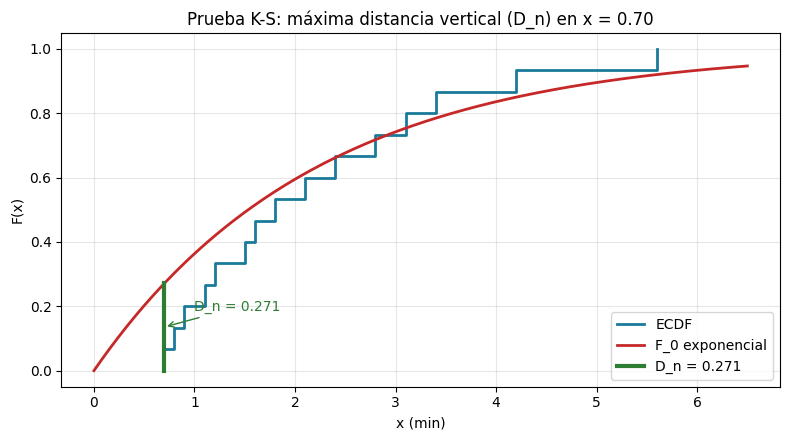

In [11]:
# Tabla completa del cálculo K-S para los 15 tiempos
F0 = 1 - np.exp(-lam_hat * x_sorted)
d_plus = np.arange(1, n+1) / n - F0
d_minus = F0 - np.arange(0, n) / n
D_each = np.maximum(np.abs(d_plus), np.abs(d_minus))
D_n = D_each.max()
i_max = int(D_each.argmax()) + 1

print(f"{'i':>3}{'x_(i)':>9}{'F_0(x_(i))':>14}{'i/n':>10}"
      f"{'(i-1)/n':>12}{'d_i+':>10}{'d_i-':>10}{'D_i':>10}")
print("-" * 80)
for i in range(n):
    marca = "  <-- max" if (i + 1) == i_max else ""
    print(f"{i+1:>3}{x_sorted[i]:>9.2f}{F0[i]:>14.4f}{(i+1)/n:>10.4f}"
          f"{i/n:>12.4f}{d_plus[i]:>+10.4f}{d_minus[i]:>+10.4f}{D_each[i]:>10.4f}{marca}")

# Valor crítico K-S clásico (tabla) para n = 15, alpha = 0.05
D_crit = 0.338
print(f"\nD_n observado:                    {D_n:.4f}  (alcanzado en i = {i_max})")
print(f"Valor crítico K-S (n=15, alpha=0.05): {D_crit:.3f}")
veredicto = "NO se rechaza" if D_n < D_crit else "SE RECHAZA"
print(f"Decisión:  {D_n:.3f} {'<' if D_n < D_crit else '>'} {D_crit:.3f}"
      f"  =>  {veredicto} la exponencial.")

# Gráfico de la máxima distancia
fig, ax = plt.subplots(figsize=(8, 4.5))
xg = np.linspace(0, 6.5, 400)
ax.step(x_sorted, np.arange(1, n+1)/n, where="post", color="#1A7A9A",
        lw=2, label="ECDF")
ax.plot(xg, 1 - np.exp(-lam_hat * xg), color="#C62828", lw=2, label="F_0 exponencial")
# Barra vertical en el máximo
x_max = x_sorted[i_max - 1]
y_emp_prev = (i_max - 1) / n
y_emp_curr = i_max / n
y_theor = F0[i_max - 1]
ax.plot([x_max, x_max], [y_emp_prev, y_theor], color="#2E7D32", lw=3,
        label=f"D_n = {D_n:.3f}")
ax.annotate(f"D_n = {D_n:.3f}",
            xy=(x_max, (y_emp_prev + y_theor) / 2),
            xytext=(x_max + 0.3, (y_emp_prev + y_theor) / 2 + 0.05),
            color="#2E7D32", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="#2E7D32"))
ax.set_xlabel("x (min)"); ax.set_ylabel("F(x)")
ax.set_title(f"Prueba K-S: máxima distancia vertical (D_n) en x = {x_max:.2f}")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Prueba de Anderson–Darling — paso a paso

$$
A^2 \;=\; -n \;-\; \frac{1}{n}\sum_{i=1}^{n}(2i-1)\Bigl[\ln F_0(X_{(i)}) + \ln\bigl(1 - F_0(X_{(n+1-i)})\bigr)\Bigr]
$$

**Idea:** pondera la discrepancia entre la empírica y la teórica por
$1/[F_0(x)(1-F_0(x))]$, un peso que *explota en las colas*. Es la prueba más potente cuando las colas importan.

**Valor crítico al 5 % (parámetros estimados):**
exponencial $= 1{,}32$ · normal y log-normal $= 0{,}75$ · Weibull $= 0{,}76$.

In [12]:
# Cálculo término a término sobre los 15 datos
F0 = 1 - np.exp(-lam_hat * x_sorted)
F0_rev = F0[::-1]
lnF = np.log(F0)
ln1mFrev = np.log(1 - F0_rev)
term = (2 * np.arange(1, n+1) - 1) / n * (lnF + ln1mFrev)
suma = term.sum()
A2 = -n - suma

print(f"{'i':>3}{'x_(i)':>9}{'F_0(x_(i))':>14}{'x_(n+1-i)':>12}"
      f"{'1-F_(n+1-i)':>15}{'ln F_i':>10}{'ln(1-Fr)':>12}{'(2i-1)/n*[]':>13}")
print("-" * 92)
for i in range(n):
    xrev = x_sorted[n - 1 - i]
    Frev = F0_rev[i]
    print(f"{i+1:>3}{x_sorted[i]:>9.2f}{F0[i]:>14.4f}{xrev:>12.2f}"
          f"{1 - Frev:>15.4f}{lnF[i]:>+10.3f}{ln1mFrev[i]:>+12.3f}{term[i]:>+13.3f}")

print("-" * 92)
print(f"{'':<63}{'suma =':>15}{suma:>+13.3f}")

A2_crit = 1.32  # exponencial, parámetro estimado, alpha = 0.05
print(f"\nA^2 = -n - suma = -{n} - ({suma:.3f}) = {A2:.3f}")
print(f"Valor crítico (exp, parámetro estimado, 5%): {A2_crit}")
veredicto = "NO se rechaza" if A2 < A2_crit else "SE RECHAZA"
print(f"Decisión:  {A2:.3f} {'<' if A2 < A2_crit else '>'} {A2_crit}"
      f"  =>  {veredicto} la exponencial.")


  i    x_(i)    F_0(x_(i))   x_(n+1-i)    1-F_(n+1-i)    ln F_i    ln(1-Fr)  (2i-1)/n*[]
--------------------------------------------------------------------------------------------
  1     0.70        0.2711        5.60         0.0796    -1.305      -2.530       -0.256
  2     0.80        0.3033        4.20         0.1499    -1.193      -1.898       -0.618
  3     0.90        0.3341        3.40         0.2152    -1.096      -1.536       -0.877
  4     1.10        0.3916        3.10         0.2464    -0.937      -1.401       -1.091
  5     1.20        0.4185        2.80         0.2822    -0.871      -1.265       -1.282
  6     1.50        0.4922        2.40         0.3381    -0.709      -1.084       -1.315
  7     1.60        0.5147        2.10         0.3872    -0.664      -0.949       -1.398
  8     1.80        0.5566        1.80         0.4434    -0.586      -0.813       -1.399
  9     2.10        0.6128        1.60         0.4853    -0.490      -0.723       -1.374
 10     2.40     

## Las tres pruebas, sobre la misma muestra

| Prueba | Estadístico | Valor crítico 5 % | Decisión |
|---|---|---|---|
| $\chi^2$ (3 intervalos fijos) | ~0{,}71 | $\chi^2_{1,\,0{,}05} = 3{,}84$ | No rechaza |
| Kolmogorov–Smirnov (tabla clásica) | 0{,}271 | $D^*_{15,\,0{,}05} = 0{,}338$ | No rechaza |
| Anderson–Darling (param. estimado) | 1{,}207 | $A^{2*}_{0{,}05} = 1{,}32$ | No rechaza |

<div class='nota'>
Las tres pruebas coinciden en <strong>no rechazar</strong> la exponencial, pero el coeficiente de variación $\mathrm{CV} = 0{,}63 < 1$ y la curvatura en <em>S</em> del Q-Q plot advierten que con más datos probablemente se rechazará. <strong>Con $n = 15$ ninguna prueba tiene suficiente potencia.</strong>
</div>

## Cierre del problema — banco completo ($n=80$)

Con más datos la situación se aclara. Repetimos la metodología sobre 80 observaciones simuladas del mismo banco, ajustando tres candidatas (exponencial, Erlang-3, Gamma) y escogiendo por Anderson–Darling y AIC.

In [13]:
np.random.seed(2026)
arrivals80 = stats.expon.rvs(scale=3.2, size=80)        # entre llegadas
services80 = stats.erlang.rvs(a=3, scale=2.18/3, size=80)  # servicios

# Estadísticos de servicios
m_s = services80.mean()
cv_s = services80.std(ddof=1) / m_s
print(f"Banco completo - tiempos de servicio (n = 80):")
print(f"  Media = {m_s:.2f} min, CV = {cv_s:.2f}")
print(f"  k sugerido por guía = 1/CV^2 = {1/cv_s**2:.1f} => Erlang-3 o Gamma\n")

def anderson_darling(data, cdf_fn):
    x_ord = np.sort(np.asarray(data, float))
    n_ = x_ord.size
    F = np.clip(cdf_fn(x_ord), 1e-12, 1 - 1e-12)
    i = np.arange(1, n_ + 1)
    return -n_ - (1/n_) * np.sum((2*i - 1) * (np.log(F) + np.log(1 - F[::-1])))

candidatas = {}

# Exponencial
sc_e = m_s
ll_e = stats.expon.logpdf(services80, scale=sc_e).sum()
candidatas["Exponencial"] = dict(
    params=f"λ = {1/sc_e:.3f}", p=1, logL=ll_e, AIC=-2*ll_e + 2,
    cdf=lambda x, s=sc_e: stats.expon.cdf(x, scale=s),
    pdf=lambda x, s=sc_e: stats.expon.pdf(x, scale=s),
)

# Erlang-3
sc_e3 = m_s / 3
ll_e3 = stats.erlang.logpdf(services80, a=3, scale=sc_e3).sum()
candidatas["Erlang-3"] = dict(
    params=f"μ_f = {1/sc_e3:.3f}", p=1, logL=ll_e3, AIC=-2*ll_e3 + 2,
    cdf=lambda x, s=sc_e3: stats.erlang.cdf(x, a=3, scale=s),
    pdf=lambda x, s=sc_e3: stats.erlang.pdf(x, a=3, scale=s),
)

# Gamma
a_g, _, b_g = stats.gamma.fit(services80, floc=0)
ll_g = stats.gamma.logpdf(services80, a_g, scale=b_g).sum()
candidatas["Gamma"] = dict(
    params=f"α = {a_g:.2f}, β = {1/b_g:.2f}", p=2, logL=ll_g, AIC=-2*ll_g + 4,
    cdf=lambda x, a=a_g, s=b_g: stats.gamma.cdf(x, a, scale=s),
    pdf=lambda x, a=a_g, s=b_g: stats.gamma.pdf(x, a, scale=s),
)

ad_crit = {"Exponencial": 1.32, "Erlang-3": 1.32, "Gamma": 1.32}

print(f"{'Distribución':<14}{'Parámetros':<26}{'log-L':>10}{'AIC':>10}"
      f"{'KS D':>9}{'A^2':>9}{'vs. crit':>13}")
print("-" * 92)
for nombre, info in candidatas.items():
    ks_d, _ = stats.kstest(services80, info["cdf"])
    a2 = anderson_darling(services80, info["cdf"])
    info["KS"] = ks_d; info["A2"] = a2
    estado = "rechazada" if a2 > ad_crit[nombre] else "no rechazada"
    print(f"{nombre:<14}{info['params']:<26}{info['logL']:>10.1f}{info['AIC']:>10.1f}"
          f"{ks_d:>9.3f}{a2:>9.3f}{estado:>13}")

mejor = min(candidatas, key=lambda k: candidatas[k]["AIC"])
print(f"\nMejor modelo por AIC: {mejor}")
print("La exponencial queda descartada por Anderson–Darling (A^2 >> 1.32).")
print("Entre Erlang-3 y Gamma, se escoge Erlang-3 por parsimonia (1 parámetro)")
print("y por interpretación física: el servicio consta de 3 etapas sucesivas.")


Banco completo - tiempos de servicio (n = 80):
  Media = 2.35 min, CV = 0.54
  k sugerido por guía = 1/CV^2 = 3.4 => Erlang-3 o Gamma

Distribución  Parámetros                     log-L       AIC     KS D      A^2     vs. crit
--------------------------------------------------------------------------------------------
Exponencial   λ = 0.425                     -148.4     298.7    0.309    9.310    rechazada
Erlang-3      μ_f = 1.276                   -121.8     245.6    0.101    0.771 no rechazada
Gamma         α = 3.86, β = 1.64            -120.5     245.1    0.087    0.589 no rechazada

Mejor modelo por AIC: Gamma
La exponencial queda descartada por Anderson–Darling (A^2 >> 1.32).
Entre Erlang-3 y Gamma, se escoge Erlang-3 por parsimonia (1 parámetro)
y por interpretación física: el servicio consta de 3 etapas sucesivas.


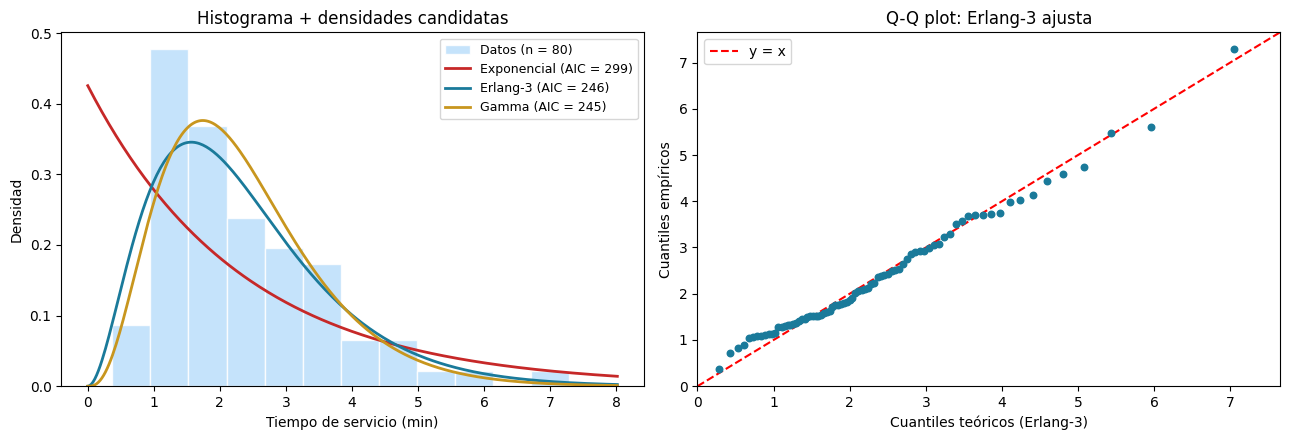


Impacto en el modelo de colas:
  Tasa de llegada λ = 0.307 cl/min
  Tráfico rho = λ * E[S] = 0.721
  Si usáramos M/M/1 (exponencial):       W_q = 6.07 min
  Correcto M/E_3/1 (Pollaczek–Khinchine): W_q = 3.91 min
  Error relativo al asumir M/M/1:         +55%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel izquierdo: histograma + densidades
xg = np.linspace(0, services80.max() * 1.1, 300)
axes[0].hist(services80, bins=12, density=True, color="#BBDEFB",
             edgecolor="white", alpha=0.85, label="Datos (n = 80)")
colors = {"Exponencial": "#C62828", "Erlang-3": "#1A7A9A", "Gamma": "#C8961E"}
for nombre, info in candidatas.items():
    axes[0].plot(xg, info["pdf"](xg), color=colors[nombre], lw=2,
                 label=f"{nombre} (AIC = {info['AIC']:.0f})")
axes[0].set_xlabel("Tiempo de servicio (min)"); axes[0].set_ylabel("Densidad")
axes[0].set_title("Histograma + densidades candidatas"); axes[0].legend(fontsize=9)

# Panel derecho: Q-Q Erlang-3 (la elegida)
data_s = np.sort(services80)
p_plot = (np.arange(1, 81) - 0.5) / 80
q_theor = stats.erlang.ppf(p_plot, a=3, scale=sc_e3)
axes[1].scatter(q_theor, data_s, color="#1A7A9A", s=22, zorder=3)
lims = [0, max(q_theor.max(), data_s.max()) * 1.05]
axes[1].plot(lims, lims, "r--", lw=1.5, label="y = x")
axes[1].set_xlabel("Cuantiles teóricos (Erlang-3)")
axes[1].set_ylabel("Cuantiles empíricos")
axes[1].set_title("Q-Q plot: Erlang-3 ajusta"); axes[1].legend()
axes[1].set_xlim(lims); axes[1].set_ylim(lims)

plt.tight_layout(); plt.show()

# Impacto sobre W_q
lam_A = 1.0 / arrivals80.mean()
rho = lam_A * m_s
ES2 = services80.var() + m_s ** 2
Wq_MM1 = rho / ((1 / m_s) * (1 - rho))
Wq_MG1 = lam_A * ES2 / (2 * (1 - rho))

print("\nImpacto en el modelo de colas:")
print(f"  Tasa de llegada λ = {lam_A:.3f} cl/min")
print(f"  Tráfico rho = λ * E[S] = {rho:.3f}")
print(f"  Si usáramos M/M/1 (exponencial):       W_q = {Wq_MM1:.2f} min")
print(f"  Correcto M/E_3/1 (Pollaczek–Khinchine): W_q = {Wq_MG1:.2f} min")
print(f"  Error relativo al asumir M/M/1:         {(Wq_MM1/Wq_MG1 - 1)*100:+.0f}%")


## ¿Qué hacer sin datos suficientes?

| Situación | Estrategia | Distribución |
|---|---|---|
| Se conocen mínimo $a$, moda $m$, máximo $b$ | Elicitación de expertos | Triangular / PERT |
| Existen benchmarks o publicaciones | Valores de literatura | Según el contexto |
| La entrada es muy incierta | Análisis de sensibilidad | Varias candidatas |
| Solo se conocen los límites $[a,b]$ | Máxima entropía | $U(a, b)$ |

**PERT:** $\E[X] = (a + 4m + b)/6$, $\Var[X] = (b-a)^2/36$.

<div class='alerta'>
<strong>La triangular no es un sustituto permanente.</strong> Sus colas lineales no representan tiempos de servicio ni de falla realistas. Se usa para prototipos, no para el modelo final.
</div>

## Cierre

- El **coeficiente de variación** es la primera señal para elegir la familia.
- Con $n < 20$ las pruebas formales tienen poco poder: confiar en el Q-Q plot y en el proceso físico.
- **Siempre** verificar independencia (autocorrelación lagueada, correlograma, runs test) *antes* de ajustar.
- **Anderson–Darling** es la prueba estándar cuando las colas importan; $\chi^2$ y K-S son sus complementos.
- La elección de distribución puede cambiar $W_q$ por un factor de 2 o más: es la diferencia entre un modelo útil y uno engañoso.

**Próximo tema — T3.2:** Verificación y Validación del modelo de simulación.